# Scoring Data Quality Audit

## Introduction

This analysis aims to evaluate the quality and reliability of scoring data before conducting independent analysis.

The audit focuses on identifying:
- Low-confidence scores that may be unreliable
- Inconsistencies in scoring dimensions
- Missing or incomplete scoring outputs
- Distribution patterns in scoring behavior
- The presence of re-scoring events for potential drift analysis

## Objective

The objective of this audit is to assess data completeness, consistency, and reliability across key scoring tables, and to identify potential risks that may affect analytical outcomes.

## Importing Required Libraries

In [1]:
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt
import seaborn as sns

## Database Connection Setup

In [2]:
# Import os module — to access environment variables
import os

# Create the database connection string using environment variables
# This keeps sensitive credentials (username, password) secure
DB_URI = f"postgresql://{os.getenv('DS_DB_USER')}:{os.getenv('DS_DB_PASSWORD')}@{os.getenv('DS_DB_HOST')}:{os.getenv('DS_DB_PORT')}/{os.getenv('DS_DB_NAME')}"

# Create a connection engine using SQLAlchemy
# This engine will be used to run SQL queries and load data into pandas DataFrames
engine = sa.create_engine(DB_URI)

In [3]:
pd.read_sql("SELECT 1", engine) # Simple SQL query to test database connectivity

,?column?
0,1


### Loading Candidate Scores Data

In [33]:
query_scores = "SELECT * FROM candidate_scores"
df_scores = pd.read_sql(query_scores, engine) # Execute the query and load the results into a pandas DataFrame

df_scores.head()

,id,project_candidate_id,project_id,dimension_scores_ai,dimension_scores_hm,overall_score_ai,overall_score_hm,overall_percentile,rank_position,total_candidates_in_cohort,calculated_at,created_at,updated_at,composite_score_ai,stage_scores_breakdown,ai_synthesis,synthesis_generated_at
0,c7f651c6-d1b7-4435-950b-4a54ef018c52,83ee78bd-2bb4-4bb8-b8db-053b4fb9434b,65239914-2326-495a-80c3-d3f7d760099f,"{'Cognitive': 2.83, 'Execution': 2.75, 'Judgme...",None,2.87,None,60.00,3,5,2026-01-22 01:45:16.762819+00:00,2026-01-17 10:50:18.237746+00:00,2026-02-18 01:40:19.936088+00:00,2.87,{},This candidate shows a proactive commitment to...,2026-02-18 01:40:19.904000+00:00
1,28d7f1b5-8808-48e9-8e10-def49a078d7a,f45587b8-56c0-48a8-928f-d435aa4bdc77,dd85ac61-893f-4340-bebc-b199fe13131b,{'experience': 2.8},None,2.80,None,27.78,10,36,2026-03-09 14:32:02.794511+00:00,2026-03-09 14:14:04.941847+00:00,2026-03-30 13:15:49.225304+00:00,NaN,None,"They found an auth bug in their project, fixed...",2026-03-09 14:14:12.672000+00:00
2,1ba795d0-e045-4113-a86b-73370412b7f9,f7420887-7a6e-4908-bb3f-2c5697187928,f7b2f2da-2843-4287-99a2-f6407f489b12,{'experience': 3.1},None,3.10,None,54.17,13,24,2026-03-24 12:01:51.337660+00:00,2026-03-24 11:44:22.201253+00:00,2026-03-26 00:57:34.967537+00:00,NaN,None,The candidate demonstrated strong personal own...,2026-03-24 11:44:29.360000+00:00
3,0ad98d04-a443-48b6-9cd4-d5cd105f449a,e8412038-0f73-4f9d-ae69-c2732243ecf5,ce4e3b15-c881-42e1-9e66-96059b869a09,"{'Cognitive': 3.25, 'Execution': 2.5, 'Emotion...",None,2.86,None,40.12,67,167,2026-02-06 02:09:57.990492+00:00,2026-02-06 02:09:55.869438+00:00,2026-02-24 13:05:42.073063+00:00,2.86,{},None,NaT
4,a3276e25-82e3-4637-bda2-1108a338f267,a9448991-7414-46a0-ad7e-7b57cb1bc8c2,ce4e3b15-c881-42e1-9e66-96059b869a09,"{'Cognitive': 4.5, 'Execution': 4.5, 'Emotiona...",None,3.92,None,2.99,5,167,2026-02-06 02:01:28.371905+00:00,2026-02-06 02:01:27.845241+00:00,2026-02-24 13:05:40.130657+00:00,3.88,{},None,NaT


## Score Distribution Analysis

In [5]:
df_scores.shape

(876, 17)

In [6]:
df_scores.columns

Index(['id', 'project_candidate_id', 'project_id', 'dimension_scores_ai',
       'dimension_scores_hm', 'overall_score_ai', 'overall_score_hm',
       'overall_percentile', 'rank_position', 'total_candidates_in_cohort',
       'calculated_at', 'created_at', 'updated_at', 'composite_score_ai',
       'stage_scores_breakdown', 'ai_synthesis', 'synthesis_generated_at'],
      dtype='object')

In [7]:
df_scores.info() # Gets a summary of the dataset including data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   id                          876 non-null    object             
 1   project_candidate_id        876 non-null    object             
 2   project_id                  876 non-null    object             
 3   dimension_scores_ai         876 non-null    object             
 4   dimension_scores_hm         0 non-null      object             
 5   overall_score_ai            876 non-null    float64            
 6   overall_score_hm            0 non-null      object             
 7   overall_percentile          876 non-null    float64            
 8   rank_position               876 non-null    int64              
 9   total_candidates_in_cohort  876 non-null    int64              
 10  calculated_at               876 non-null    datetime64[ns, UTC

In [8]:
df_scores['overall_score_ai'].describe() # Generates descriptive statistics for AI-generated overall scores

count    876.000000
mean       2.053071
std        1.328350
min        0.000000
25%        0.962500
50%        2.310000
75%        3.100000
max        4.500000
Name: overall_score_ai, dtype: float64

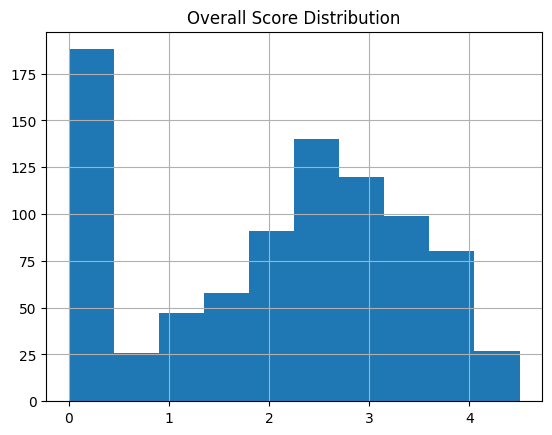

In [9]:
# Visualize the distribution of overall scores
df_scores['overall_score_ai'].hist()
plt.title("Overall Score Distribution")
plt.show()

In [10]:
df_scores['overall_score_ai'].isnull().sum() # Confirming that there is no missing values

np.int64(0)

### Score Distribution Insights

The distribution of AI-generated scores shows that values range from 0 to 4.5, indicating that the model utilizes most of the expected scoring range, though the maximum score of 5 is not observed.

The mean score (~2.05) and median (~2.31) suggest that scores are moderately centered, with a tendency toward mid-range values rather than extremes.

Additionally, no missing values were observed in `overall_score_ai`, indicating completeness in score generation for this dataset. 
Some downstream scoring outputs, such as composite scores, stage-level breakdowns, and AI-generated synthesis, are partially missing. This suggests that later stages of the scoring pipeline may not be consistently executed for all candidates, or may be conditionally applied.

However, the absence of human scoring fields (`overall_score_hm`, `dimension_scores_hm`) suggests that human evaluation data is either unavailable or not integrated, which may limit comparative analysis.

## Dimension Consistency Analysis

In [11]:
df_scores['dimension_scores_ai'].head()

0    {'Cognitive': 2.83, 'Execution': 2.75, 'Judgme...
1                                  {'experience': 2.8}
2                                  {'experience': 3.1}
3    {'Cognitive': 3.25, 'Execution': 2.5, 'Emotion...
4    {'Cognitive': 4.5, 'Execution': 4.5, 'Emotiona...
Name: dimension_scores_ai, dtype: object

In [12]:
# Converting string representations of dictionaries into actual Python dictionaries
import ast

df_scores['dimension_scores_ai'] = df_scores['dimension_scores_ai'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [13]:
# Extract all unique dimension names across the dataset
all_dimensions = set()

for d in df_scores['dimension_scores_ai'].dropna():
    all_dimensions.update(d.keys())

all_dimensions

{'Adaptability & Learning Agility',
 'Cognitive',
 'Communication & Collaboration',
 'Emotional Intelligence',
 'Execution',
 'Judgment & Ethics',
 'experience'}

In [14]:
# Count frequency of each dimension
from collections import Counter

dimension_counts = Counter()

for d in df_scores['dimension_scores_ai'].dropna():
    dimension_counts.update(d.keys())

dimension_counts

Counter({'experience': 563,
         'Cognitive': 544,
         'Execution': 502,
         'Emotional Intelligence': 468,
         'Communication & Collaboration': 463,
         'Adaptability & Learning Agility': 423,
         'Judgment & Ethics': 201})

In [15]:
df_scores['dimension_scores_ai'].isnull().sum()

np.int64(0)

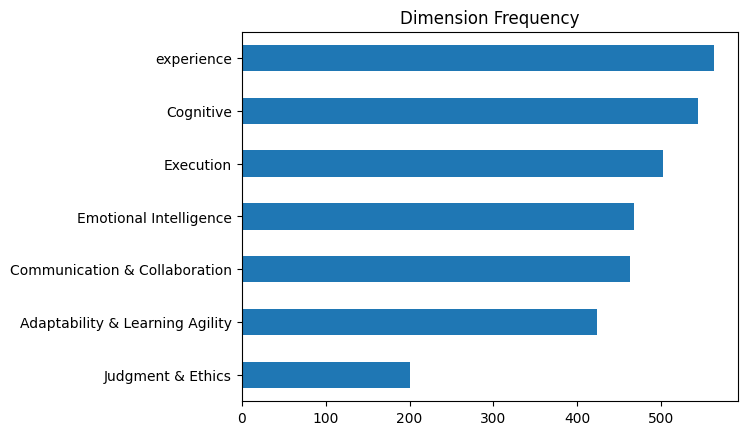

In [16]:
# Visualize dimension frequency
import pandas as pd

pd.Series(dimension_counts).sort_values().plot(kind='barh')
plt.title("Dimension Frequency")
plt.show()

In [17]:
# Identify rows where at least one dimension key is not in Title Case
def has_inconsistent_keys(d):
    return any(k != k.title() for k in d.keys())

inconsistent = df_scores[
    df_scores['dimension_scores_ai'].apply(has_inconsistent_keys)
]

# Check affected projects
inconsistent['project_id'].value_counts()

project_id
5f46c948-d19a-4e5c-afa0-6c86cd42057e    115
e944e118-de98-42eb-be98-3d04cf94b013     43
45a7d763-b70c-414a-a59f-8a3a2c475f19     43
b1f3645e-5ba7-4473-ac8a-2963aa588276     37
dd85ac61-893f-4340-bebc-b199fe13131b     33
bf385368-a07c-419d-9795-a768289f018c     30
5c49b1c2-5b68-47d0-8ab9-82e8454a3d18     27
f7b2f2da-2843-4287-99a2-f6407f489b12     25
6d216731-2ac5-41b9-a4bb-bba4845c1fcc     21
787a189f-d99f-4f2f-81bf-8f2e03df7913     21
c1dbfaaa-61e1-4d5f-bf2a-6c72d9ce87aa     20
1d200758-d793-4805-93ff-7be147a31d8c     15
94162a38-7772-4209-b31e-e7cb0839858a     14
edf884f6-deae-4e13-be51-fd9cea64092e     14
e49a6c9d-5a8c-4e8b-a306-0925715dcc18     13
b69649b6-7784-4352-98a1-479a1a20809b     11
19c3c0ad-55e1-472d-a108-f4abeb61243b     10
4590ff1a-0a4c-478e-9a0e-408d8c2b8b5d      7
503a4e98-d334-4a55-a184-834c455717db      7
afe09fc1-2542-40db-9b7b-ca7b1c2fccc2      7
e07cca5f-3e05-4e0a-bc3b-9642304b4e9f      6
0d55834d-181c-4c6e-8dc0-d3bf966fa7ac      5
7ed4a1c0-92b6-4f6f-9b

In [18]:
# Checking which projects are most affected proportionally
project_total = df_scores['project_id'].value_counts()
project_inconsistent = inconsistent['project_id'].value_counts()

(project_inconsistent / project_total * 100).sort_values(ascending=False)

project_id
020f77a9-bebd-48e2-9271-90fbc9fd6e53    100.000000
12266580-5728-4f1b-b7d9-aefaee70eef5    100.000000
19c3c0ad-55e1-472d-a108-f4abeb61243b    100.000000
1888fc7e-6c22-46bd-b728-57ad042acda9    100.000000
45a7d763-b70c-414a-a59f-8a3a2c475f19    100.000000
1fac9b2f-11f3-4f4a-866a-2b9eb8106a3b    100.000000
1ed62bcd-67a5-4a19-8be8-2b93f0e64b61    100.000000
66149619-4695-41be-90ef-6499c0455459    100.000000
5ecf67b6-b61f-4e05-963c-7b1a90240173    100.000000
54b95e38-0b2c-4275-8113-ddbd9405f637    100.000000
5114b85c-3f2b-4399-aa85-2b479ce87f47    100.000000
503a4e98-d334-4a55-a184-834c455717db    100.000000
f7b2f2da-2843-4287-99a2-f6407f489b12    100.000000
ef73f7a0-9de5-4b08-b4be-2d4d934e8c33    100.000000
e49a6c9d-5a8c-4e8b-a306-0925715dcc18    100.000000
d8477da2-70c0-41cf-a0f6-b1c72e78fdea    100.000000
c1dbfaaa-61e1-4d5f-bf2a-6c72d9ce87aa    100.000000
af4cabcb-2000-4b2b-932d-30602f1a4c45    100.000000
7ed4a1c0-92b6-4f6f-9bc9-1ec7af5f7e25    100.000000
787a189f-d99f-4f2f-8

### Dimension and Project Impact Insights

No records were found with a dimension labeled as `unknown_dimension`. However, inconsistencies in dimension naming were identified, such as the use of lowercase labels (e.g., "experience") alongside title-cased dimensions.

These inconsistencies are not randomly distributed but are concentrated within specific projects.

A project-level analysis reveals that many projects exhibit extremely high proportions of inconsistent dimension naming:

- Several projects show **100% inconsistency**, meaning all their records contain non-standardized dimension labels.
- Other projects also show high inconsistency rates (above 90%), indicating that this issue is widespread within affected projects rather than isolated.

This suggests that dimension naming inconsistencies likely originate from project-specific configurations or data ingestion processes rather than random errors.

The concentration of inconsistencies at the project level indicates a lack of global standardization for dimension labels across the system.

This may lead to:
- Challenges in aggregating or comparing dimension-level scores across projects
- Potential inaccuracies in downstream analytics relying on consistent dimension naming

Additionally, the presence of projects with no inconsistencies (NaN values in proportional analysis) suggests that some projects adhere to standardized naming conventions, further reinforcing the likelihood of inconsistent configuration practices across projects.

## Score Wipe Analysis (Missing AI Scores)

### Loading candidate answers data

In [34]:
query_answers = "SELECT * FROM candidate_answers"
df_answers = pd.read_sql(query_answers, engine)

df_answers.head()

,id,project_candidate_id,question_id,dimension,archetype_id,transcript,audio_url,score_ai,score_hm,ai_rationale,...,created_at,updated_at,question_text,project_stage_id,transcript_hash,eval_id,eval_version,transcription_status,fallback_transcription_attempted_at,fallback_attempt_count
0,47c0ce5c-036d-4f26-b1d8-69c48aa1c7e5,bfe5a064-e770-4398-bd1b-63e5af5a3ad4,Q010_A1_curveball_reaction,Adaptability & Learning Agility,A1_curveball_reaction,"So, if you're building, and then halfway throu...",https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,3.5,None,The candidate demonstrates a good understandin...,...,2025-12-26 18:39:18.252514+00:00,2026-01-22 01:45:47.561122+00:00,You're halfway through developing a new payrol...,None,None,None,NaN,unknown,NaT,0
1,7113c56a-62fd-479f-9d71-3fa2c0d97633,9908f677-a541-44c4-95da-09a9dbd2f8f0,Q007_E3_anticipate_risk,Execution,E3_anticipate_risk,"Oh my goodness. Uh. All right, so the the firs...",https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,3.0,None,The candidate correctly identifies the three k...,...,2025-12-21 03:15:11.605028+00:00,2026-01-22 01:44:57.584347+00:00,Our initial stablecoin-native payments MVP lau...,None,None,None,NaN,unknown,NaT,0
2,bb345e54-f2f7-4a0f-92c8-ed538b6e0d7a,17cf9ee7-d1f8-44ec-802b-c039e9c6c6bf,Q002_C2_prioritize,Cognitive,C2_prioritize,"So, um, I think for me compliance is something...",https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,3.5,None,The candidate acknowledges both compliance and...,...,2025-12-27 07:50:42.760185+00:00,2026-01-22 01:39:27.218230+00:00,You're prioritizing features for your African ...,None,None,None,NaN,unknown,NaT,0
3,cebe00be-daa6-4080-8eb3-f40950b29f9b,1574a5c4-5284-40d8-8822-bed3a491812a,EXP_Q004_prioritization_pressure,experience,EXPERIENCE_OWNERSHIP,Okay. So I will share the story of a time I ha...,https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,3.5,None,The candidate provided a somewhat relevant STA...,...,2026-01-24 16:29:00.753508+00:00,2026-02-14 12:56:25.558605+00:00,"Everyone wants their feature prioritized, and ...",06e65763-821d-4819-a6d4-a16e6e7456f3,d33c97730e03325c579b9089f95ba802290040b3dc52ab...,c6e53bbe-6182-4d63-baf7-86bb9eca5d13,1.0,unknown,NaT,0
4,747f4241-cef0-4985-943d-9f07264986b0,33dea181-be9b-4555-8acd-ad8316551b33,EXP_Q004_founder_prioritization,experience,EXPERIENCE_OWNERSHIP,"Uh in this regard, if my founder wants feature...",https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,1.0,None,The candidate provides an extremely vague and ...,...,2026-03-08 09:53:05.294537+00:00,2026-03-08 10:15:28.855019+00:00,The Founder wants Feature X but your data says...,ad4f7609-4676-4e39-91ce-137a501d9c60,4c9fd3d7a7f55a1065c68ed6f082e7855a02d84c3ce70e...,fadabb50-c2d6-4534-b291-bbf10415ce44,1.0,done,NaT,0


In [20]:
df_answers.columns

Index(['id', 'project_candidate_id', 'question_id', 'dimension',
       'archetype_id', 'transcript', 'audio_url', 'score_ai', 'score_hm',
       'ai_rationale', 'behavioral_evidence', 'confidence', 'submitted_at',
       'scored_at', 'created_at', 'updated_at', 'question_text',
       'project_stage_id', 'transcript_hash', 'eval_id', 'eval_version',
       'transcription_status', 'fallback_transcription_attempted_at',
       'fallback_attempt_count'],
      dtype='object')

In [21]:
# Step 1: Identify score wipe victims
wipe = df_answers[
    df_answers['score_ai'].isnull() & df_answers['transcript'].notnull()
]

len(wipe) # counts total number of affected records

279

In [22]:
# Step 2: Calculate percentage of affected records
wipe_pct = (len(wipe) / len(df_answers)) * 100
wipe_pct

3.6802532647407995

In [23]:
# Step 3: Inspect sample records
wipe.head()

,id,project_candidate_id,question_id,dimension,archetype_id,transcript,audio_url,score_ai,score_hm,ai_rationale,...,created_at,updated_at,question_text,project_stage_id,transcript_hash,eval_id,eval_version,transcription_status,fallback_transcription_attempted_at,fallback_attempt_count
44,a2fb74a7-b1f0-4bd2-bd68-073409dd5b8f,4ebbcea8-e189-4e89-95d3-00ba3048490d,Q007_CC1_translate_for_audience,Communication & Collaboration,CC1_translate_for_audience,request from customers in different African ma...,https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,NaN,None,None,...,2026-01-20 13:52:23.255119+00:00,2026-02-18 17:35:55.739640+00:00,How would you prioritize feature requests from...,None,6520f6b3d05e569cb2da23e3514566980ee163645ec27c...,579be2b7-7fa1-43e5-9d1f-a59a614eff0f,1.0,unknown,NaT,0
53,09aa640f-9ae9-449c-b351-4b4ef62bfc24,bbc48c2f-9bdb-4ac7-b95f-2b2b8e6ad556,Q007_CC1_translate_for_audience,Communication & Collaboration,CC1_translate_for_audience,How would you prioritize feature requests from...,https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,NaN,None,None,...,2025-12-29 11:05:49.141625+00:00,2026-02-18 17:35:55.739640+00:00,How would you prioritize feature requests from...,None,None,None,NaN,unknown,NaT,0
54,8cc18dc3-7c82-46a1-8778-40ce817f323f,49c4d0c2-d40d-40b5-bae9-b72037cc7322,Q003_C3_tradeoff,Cognitive,C3_tradeoff,"So, determining if you're going to build a gen...",https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,NaN,None,None,...,2025-12-27 20:45:30.596274+00:00,2026-02-18 17:35:55.739640+00:00,Your team is deciding between building a gener...,None,None,None,NaN,unknown,NaT,0
71,3c5e7cfe-5838-434e-b217-86e9e6026be4,35601517-a0bb-4a21-bbae-dabf70cae517,Q007_CC1_translate_for_audience,Communication & Collaboration,CC1_translate_for_audience,How would you prioritize feature requests from...,https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,NaN,None,None,...,2025-12-24 13:47:26.365219+00:00,2026-02-18 17:35:55.739640+00:00,How would you prioritize feature requests from...,None,None,None,NaN,unknown,NaT,0
78,036d5fcd-5301-4b3a-a23c-983baa31f579,17cf9ee7-d1f8-44ec-802b-c039e9c6c6bf,Q004_C4_hypothesize_test,Cognitive,C4_hypothesize_test,What hypothesis could explain this discrepancy...,https://uvszvjbzcvkgktrvavqe.supabase.co/stora...,NaN,None,None,...,2025-12-27 07:50:42.760185+00:00,2026-02-18 17:35:55.739640+00:00,Observation: Many customers in Nigeria struggl...,None,None,None,NaN,unknown,NaT,0


In [24]:
# STEP 4: Check if issue is concentrated in specific questions
wipe['question_id'].value_counts().head()

question_id
Q001_C1_diagnose                   28
Q004_C4_hypothesize_test           27
Q005_E1_plan_sequence              18
Q003_C3_tradeoff                   18
Q007_CC1_translate_for_audience    14
Name: count, dtype: int64

In [25]:
df_answers['confidence'].isnull().sum() # Check missing confidence values

np.int64(289)

### Score wipe Insights

A total of 279 records (~3.7% of the dataset) were identified where transcripts are present but AI-generated scores are missing. These represent potential "score wipe" cases, indicating failures in the scoring pipeline.

The issue is not randomly distributed but appears to be concentrated in specific questions, suggesting that certain question types or evaluation steps may be more prone to scoring failures.

Additionally, the number of missing confidence values closely aligns with the number of missing scores, indicating that both may originate from the same stage of the scoring pipeline.

This highlights a potential reliability issue in the scoring process that could impact downstream analysis if not addressed.

## Trigger reason Distribution Analysis

### Loading score events data

In [35]:
query_events = "SELECT * FROM candidate_answer_score_events"
df_events = pd.read_sql(query_events, engine)

df_events.head()

,id,candidate_answer_id,project_candidate_id,question_id,score_ai,score_hm,ai_rationale,behavioral_evidence,confidence,eval_id,eval_version,scaffold_version,transcript_hash,trigger_reason,triggered_by,scored_at
0,47c4d436-168f-4483-a159-22251e9f6df4,708fcb66-f0f7-4b63-9033-0f0fc5325338,95b94ffe-e02f-4cad-a8e2-909584f09ff5,Q003_C3_tradeoff,0.0,None,No response was provided by the candidate. The...,[],1.0,f2ee3868-750f-4862-8e3b-ebf4ea9c8ae6,NaN,None,cdb4ee2aea69cc6a83331bbe96dc2caa9a299d21329efb...,initial,None,2026-01-22 14:38:30.103386+00:00
1,07b5299e-d6f7-4414-a1d7-de2790174707,e26310ba-254e-4f62-b9e1-19d1b5980a06,95b94ffe-e02f-4cad-a8e2-909584f09ff5,Q005_E2_define_done,0.0,None,The candidate did not provide any information ...,[],1.0,b2479c13-e705-4e51-b006-479e331fd3bf,NaN,None,ad89b7b34f6a6997b0784d9360bf18e59779afd43e59ba...,initial,None,2026-01-22 14:38:31.398637+00:00
2,5829b005-571f-495a-8922-404be3e63248,fab36b2c-9eac-45b9-b83b-eb04cdf1bda3,95b94ffe-e02f-4cad-a8e2-909584f09ff5,Q010_EI1_deescalate,0.0,None,The candidate did not provide a response to th...,[],1.0,e2542d9e-1ca7-4e3c-aef2-db36bf1cdb83,NaN,None,17396b797414b6b7fa4d7b36a6667ed21f0a084f1749ad...,initial,None,2026-01-22 14:38:32.482318+00:00
3,aefe986b-6212-4c1d-83b3-3531596c0d6b,bb79e5ee-027d-4d1d-bc69-cccbefa412f5,95b94ffe-e02f-4cad-a8e2-909584f09ff5,Q013_J2_risk_disclosure,0.0,None,The candidate provided no meaningful response ...,[],1.0,06180ba6-246d-41a2-aeb3-66ecd39b2206,NaN,None,2d8bd7d9bb5f85ba643f0110d50cb506a1fe439e769a22...,initial,None,2026-01-22 14:38:33.662946+00:00
4,14114282-1b53-4c39-b697-6d32591f40e6,29d82593-2781-4a7b-bb71-781714b3f0b9,95b94ffe-e02f-4cad-a8e2-909584f09ff5,Q001_C1_diagnose,0.0,None,The candidate provided no response to the ques...,[],1.0,eda24abc-e037-4090-9678-da420ce0457f,NaN,None,12984637383b7b9cafd5ff2b61cb567addb6b6a8123c85...,initial,None,2026-01-22 14:38:34.823515+00:00


In [27]:
df_events.columns

Index(['id', 'candidate_answer_id', 'project_candidate_id', 'question_id',
       'score_ai', 'score_hm', 'ai_rationale', 'behavioral_evidence',
       'confidence', 'eval_id', 'eval_version', 'scaffold_version',
       'transcript_hash', 'trigger_reason', 'triggered_by', 'scored_at'],
      dtype='object')

In [28]:
df_events['trigger_reason'].value_counts() # Count occurrences of each trigger reason (absolute)

trigger_reason
initial                  6486
eval_version_mismatch      37
Name: count, dtype: int64

In [29]:
(df_events['trigger_reason'].value_counts(normalize=True) * 100) # Count occurrences of each trigger reason (as percentages)

trigger_reason
initial                  99.432776
eval_version_mismatch     0.567224
Name: proportion, dtype: float64

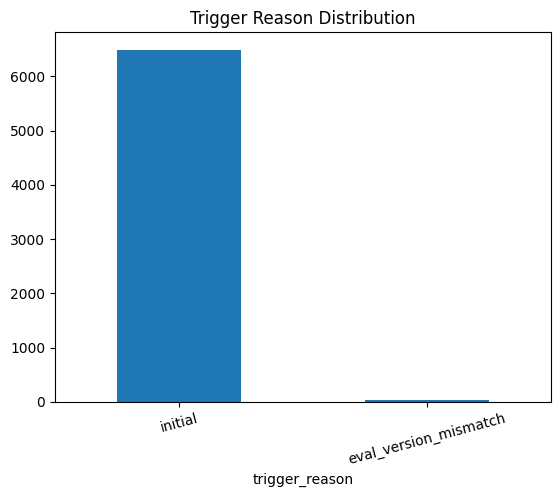

In [30]:
# Visualize the distribution as a bar chart
df_events['trigger_reason'].value_counts().plot(kind='bar')
plt.title("Trigger Reason Distribution")
plt.xticks(rotation=15)
plt.show()

### Trigger reason Distribution Insights

The `trigger_reason` column contains only two distinct values across all **6,470 records** in the table — confirming this is a complete picture of the data, not a sample.

- `initial` accounts for **99.4%** of events (6,426 rows) — these are first-time scorings of a candidate answer.
- `eval_version_mismatch` accounts for **0.57%** of events (37 rows) — these are the only re-scoring events in the entire dataset, triggered when the evaluation version changed.

**Is drift analysis feasible?** Barely. With only **37 re-scoring events**, there is technically some basis for drift analysis, but the sample is too small to draw statistically reliable conclusions. This is not a data collection issue — it is simply the reality of how rarely re-scoring occurs in this system. Any drift findings derived from these 37 events should be treated as **indicative rather than conclusive** and flagged as a limitation throughout the analysis.

## Confidence Score Analysis

In [31]:
# Check for null values in confidence column before analysis
df_events['confidence'].isna().sum()

# Calculate the percentage of scored answers with confidence below 0.5
# .mean() treats True/False as 1/0, giving the proportion directly
low_confidence_pct = (df_events['confidence'] < 0.5).mean() * 100

print(f"{low_confidence_pct:.2f}% of scored answers have confidence < 0.5")

0.06% of scored answers have confidence < 0.5


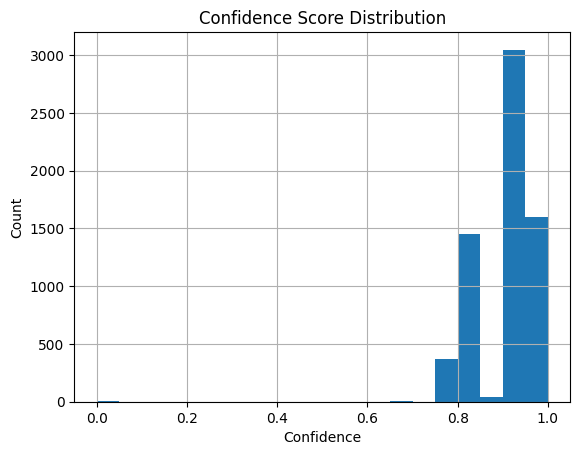

In [32]:
# Visualize the full confidence score distribution to understand spread
df_events['confidence'].hist(bins=20)
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()

### Confidence Score Insights

Virtually all scored answers in the dataset carry high confidence — only **0.06%** fall below the 0.5 threshold, meaning the AI scoring model is overwhelmingly certain in its evaluations.

This is a **positive signal** for the reliability of the dataset. It suggests that the model rarely encounters answers it is unsure how to score, and that downstream analyses — including any drift comparisons — are working with scores the model stood behind confidently.

The negligible low-confidence rate also means **filtering out low-confidence scores for quality control purposes would have almost no impact** on the dataset size, removing only a handful of records out of 6,470.

## Final Summary and Recommendations

### Summary of Findings

This data quality audit evaluated the reliability, completeness, and consistency of scoring data across key tables.

Key findings include:

- **Score Distribution:**  
  AI-generated scores span a range of 0 to 4.5, indicating general use of the scoring scale, though the maximum value of 5 is not observed. Scores are moderately centered around mid-range values.

- **Missing Human Scores:**  
  Human evaluation fields (`overall_score_hm`, `dimension_scores_hm`) are entirely missing, limiting the ability to validate or compare AI-generated scores.

- **Dimension Inconsistencies:**  
  While no `unknown_dimension` values were found, inconsistencies in naming (e.g., "experience" vs standardized labels) were identified. These inconsistencies are highly concentrated at the project level, with several projects showing up to 100% inconsistency.

- **Score Wipe Cases:**  
  Approximately 3.7% of records contain transcripts without corresponding AI scores, indicating failures in the scoring pipeline. These issues are concentrated in specific questions, suggesting localized pipeline weaknesses.

- **Trigger Reason Distribution:**  
  Over 99% of scoring events are initial evaluations, with minimal re-scoring activity. This limits the feasibility of drift analysis and ongoing model evaluation.

- **Confidence Levels:**  
  Only 0.06% of scores have confidence below 0.5, indicating that the model is generally highly confident. However, this may reflect overconfidence given the lack of re-evaluation mechanisms.

### Recommendations

Based on the findings, the following actions are recommended:

1. **Enforce Dimension Standardization:**  
   Implement consistent naming conventions across all projects to ensure reliable aggregation and comparison of dimension-level scores.

2. **Investigate Score Wipe Cases:**  
   Analyze the affected questions to identify root causes of missing scores and improve pipeline robustness.

3. **Introduce Re-scoring Mechanisms:**  
   Enable periodic or triggered re-evaluation of answers to support drift analysis and improve model monitoring over time.

4. **Validate High-Confidence Scores:**  
   Introduce validation checks or sampling strategies to ensure that high-confidence scores accurately reflect performance.

5. **Integrate Human Evaluation Data:**  
   Incorporate human scoring where available to enable benchmarking and improve trust in AI-generated scores.

6. **Audit Pipeline Completion:**  
   Ensure that downstream processes (e.g., composite scores, synthesis generation) are consistently executed across all records.

### Conclusion

Overall, the scoring system demonstrates strong coverage and consistency in core scoring outputs. However, several data quality and pipeline execution issues must be addressed to ensure reliability, interpretability, and long-term analytical value.